In [83]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt
import time

In [84]:
rootfolder = '..'

Useful function for plot a 2D dictionary

In [85]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Define a function that implements the OMP

In [86]:
def OMP(s, D, L, tau):
    M, N = D.shape
    x_OMP = np.zeros(N)

    # residual
    r = s.copy()

    # support set
    omega = []

    while np.count_nonzero(x_OMP) < L and np.linalg.norm(r, ord=2) > tau:
        # SWEEP STEP
        # compute the residual w.r.t. each column of D
        e = np.zeros(N)
        for j in range(N):
            e[j] = (np.linalg.norm(r, ord=2) ** 2) - (r.T @ D[:, j]) ** 2

        # find the column of D that matches at best r
        jStar = np.argmin(e)

        # UPDATE the support set with the jStar coefficient
        if jStar not in omega:
            omega.append(jStar)
        else:
            break

        # update the coefficients by solving the least square problem min ||D_omega x - s||
        D_omega = D[:, omega]
        x = np.linalg.solve(D_omega.T @ D_omega, D_omega.T @ s)
        x_OMP[omega] = x

        # update the residual
        r = s - D @ x_OMP

    return x_OMP

Load the image and rescale it in $[0,1]$

In [87]:
img = imread(f'{rootfolder}/data/peppers256.png') / 255
# img = imread(f'{rootfolder}/data/barbara.png') / 255
# img = imread(f'{rootfolder}/data/Lena512.png') / 255

imsz = img.shape

# patch size
p = 8

# number of elements in the patch
M = p ** 2

Corrupt the image with white gaussian noise

In [88]:
sigma_noise = 20/255
noisy_img = img + sigma_noise * np.random.normal(size=imsz)

Percentage of removed pixel

In [89]:
perc_of_removed_pixels = 0.25

Arbitrarily remove pixels setting them to zero

In [90]:
# create a vector with all the indexes of the image
idx = np.arange(imsz[0] * imsz[1])

# shuffle it and take the target percentage of indexes
idx = np.random.permutation(idx)[:int(perc_of_removed_pixels * idx.size)]

# the mask is 0 for the chosen idx, 1 elsewhere
msk = np.ones(imsz).flatten()
msk[idx] = 0
msk = msk.reshape(imsz)

# apply the mask: set to 0 some elements in the noisy image
noisy_img = noisy_img * msk

Compute the psnr of the noisy input

In [91]:
psnr_noisy = 10 * np.log10(1 / np.mean((img - noisy_img)**2))

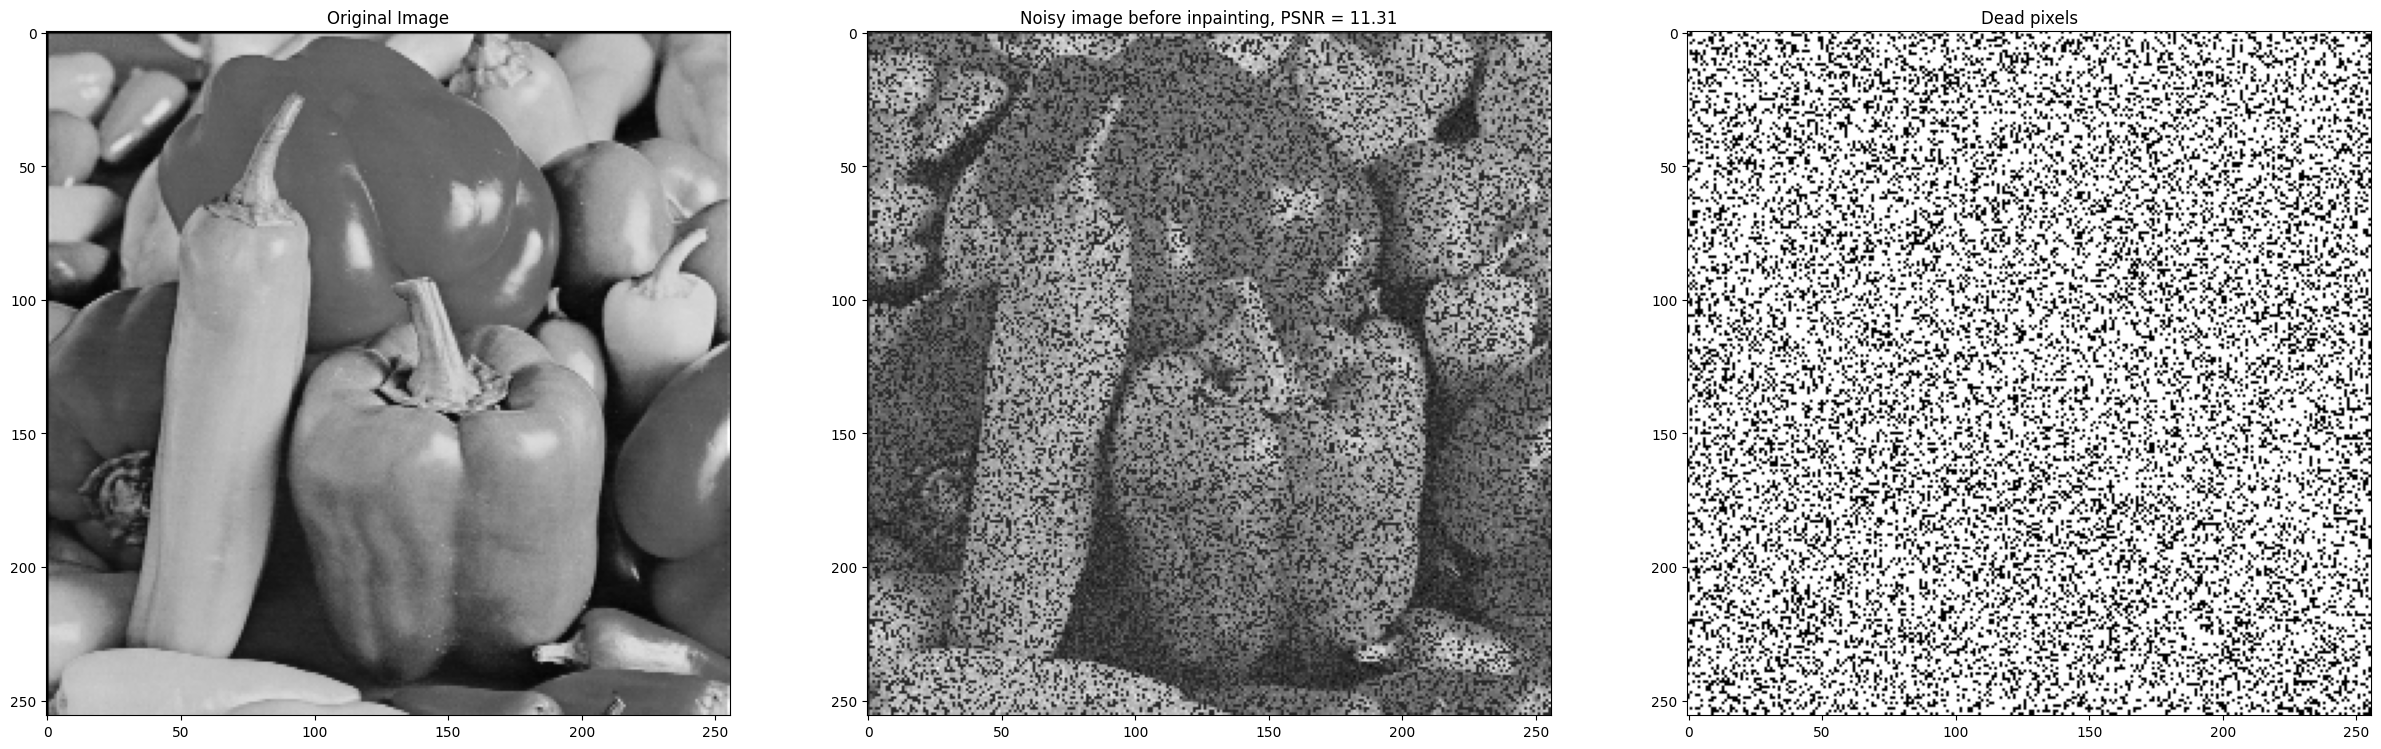

In [92]:
fig, ax = plt.subplots(1, 3, figsize=(30, 10))

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original Image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image before inpainting, PSNR = {psnr_noisy:.2f}')

ax[2].imshow(msk, cmap='gray')
ax[2].set_title('Dead pixels')

plt.show()

Load and display the dictionary learned from patches

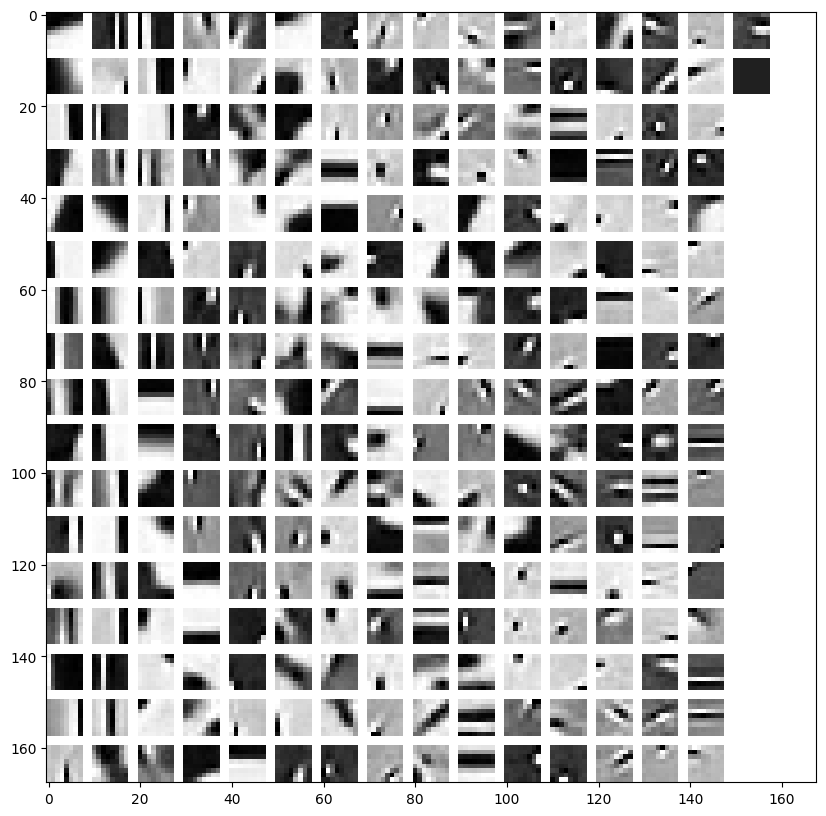

In [93]:
D = loadmat(f'{rootfolder}/data/dict_nat_img.mat')['D']

# add a constant atom to D, KSVD was trained over patches with zero mean - and normalize it
# UPDATE D
constant_atom = np.ones((D.shape[0], 1)) / np.linalg.norm(np.ones((D.shape[0], 1)))
D = np.hstack((D, constant_atom))

# display the dictionary
D_img = get_dictionary_img(D)

plt.figure(figsize=(10,10))
plt.imshow(D_img, cmap='gray')

Inpainting
----------


In [94]:
# SET stopping criteria of OMP
# orthogonal matching pursuit uses sparsity and errors as stopping criteria
L = M // 2

# initialize the estimated image
img_hat = np.zeros_like(img)

# initialize the weight matrix
weights = np.zeros_like(img)

# define the step (=p for non overlapping paches)
STEP = 4 # STEP = 1 might be very time consuming, start with larger STEP

Operate patchwise

In [95]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = noisy_img[i : i+p, j : j+p].flatten()

        # patch extracted from the mask
        m = msk[i : i+p, j : j+p].flatten()

        # design the projection operator over the current patch
        proj = np.diag(m)

        # tau should be proportional to the number of pixels remaining in the patch
        tau = 1.15 * sigma_noise * np.sqrt(np.count_nonzero(m))

        # sparse coding w.r.t. PD the inpainted dictionary using L and tau as stopping criteria
        x = OMP(s, proj @ D, L, tau)

        # reconstruction: synthesis w.r.t. D the dictionary yielding sparse representation
        s_hat = D @ x

        # use uniform weights for aggregation
        w = 1

        # put the denoised patch into the estimated image using uniform weights
        # UPDATE img_hat
        img_hat[i : i+p, j : j+p] += w * s_hat.reshape(p, p)

        # store the weight of the current patch in the weight matrix
        # UPDATE weights
        weights[i : i+p, j : j+p] += w

Normalize the estimated image with the computed weights

In [96]:
img_hat = img_hat / weights

Compute the psnr of the estimated image

In [97]:
psnr_hat = 10 * np.log10(1 / np.mean((img - img_hat)**2))

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 28.31')

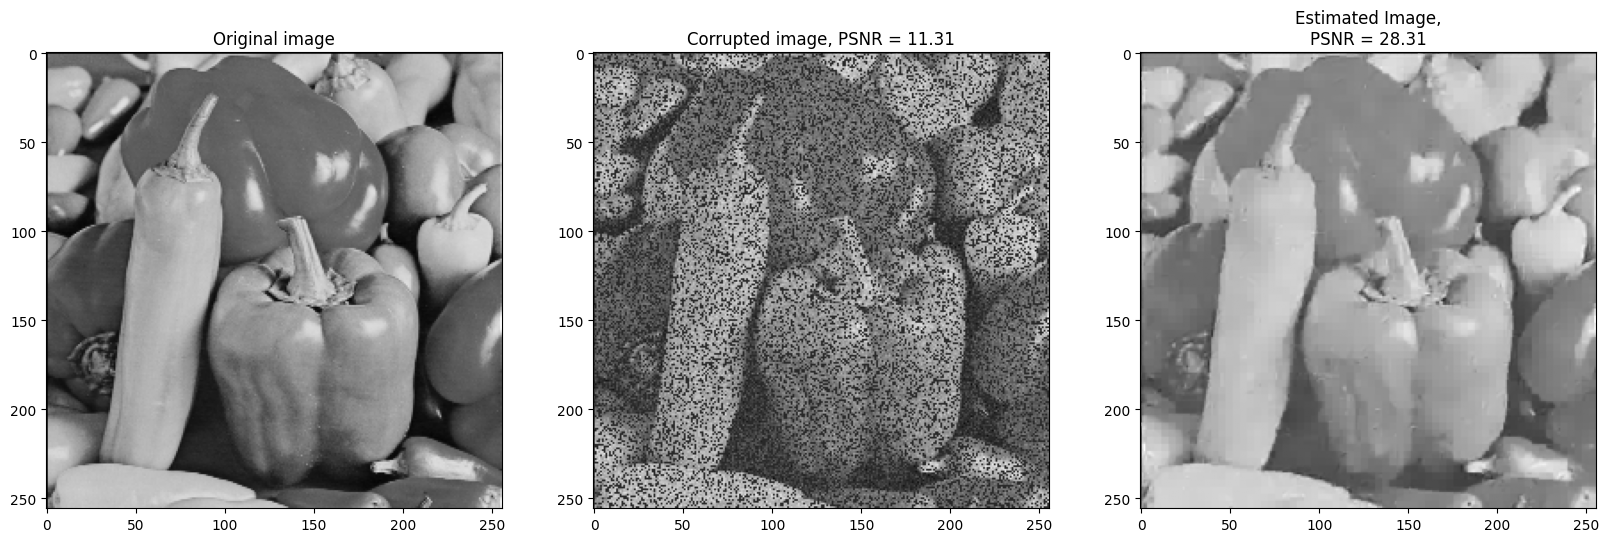

In [98]:
fig, ax = plt.subplots(1, 3, figsize=(20, 10))

ax[0].imshow(img, cmap='gray')
ax[0].set_title(f'Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Corrupted image, PSNR = {psnr_noisy:.2f}')

ax[2].imshow(img_hat, cmap='gray')
ax[2].set_title(f'Estimated Image,\nPSNR = {psnr_hat:.2f}')